# EDA - Processed Data

## Outcome

`outcome` = 0, se `review_score` ∈ {3, 4, 5} (Avaliação neutra ou positiva);
`outcome` = 1, se `review_score` ∈ {1, 2} (Avaliação negativa).


## Features analyzed

| Domínio | Variáveis Iniciais | Variáveis Criadas |
|---|---|---|
| **Geográfico** | `customer_city`, `customer_state` |--- |
| **Financeiro** | `total_price`, `avg_price`, `total_freight`, `avg_freight`, `total_payment`, `avg_payment`| `is_high_value_order`, `is_high_freight_ratio`, `installment_value`,`is_high_installments`| 
| **Pedido** | `n_items`, `n_item_distinct_categ`, `n_items_missing_info`, `max_installments`, `n_payments_type`|--- |
| **Produto** | `avg_weight`, `avg_length`, `avg_height`, `avg_width`| `volume_cm3`,  `is_heavy_item`, `is_large_item`|
| **Temporal** | `order_purchase_timestamp`| `purchase_weekday`, `purchase_month`|
| **Logístico** | `order_delivered_customer_date`, `order_estimated_delivery_date` | `is_delayed`, `is_slightly_delayed`, `is_severely_delayed`|

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from app.config.settings import PROJECT_DIR, PROCESSED_DATA_DIR, date_cols
from app.data import get_features
from app.data.utils import find_specific_variables


In [2]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Processed Data

In [3]:
df_processed = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "processed_dataset.parquet"))

print(df_processed.shape)
df_processed.head()

(95832, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,total_price,avg_price,total_freight,avg_freight,n_items_missing_info,n_items,n_item_distinct_categ,avg_weight,avg_length,avg_height,avg_width,total_payment,avg_payment,max_installments,n_payments_type,review_score,review_score_outcome
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,29.99,29.99,8.72,8.72,0.0,1.0,1.0,500.0,19.0,8.0,13.0,38.71,12.903333,1.0,3.0,4.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.177924,-44.660711,118.70,118.70,22.76,22.76,0.0,1.0,1.0,400.0,19.0,13.0,19.0,141.46,141.460000,1.0,1.0,4.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,159.90,159.90,19.22,19.22,0.0,1.0,1.0,420.0,24.0,19.0,21.0,179.12,179.120000,3.0,1.0,5.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774190,-35.271143,45.00,45.00,27.20,27.20,0.0,1.0,1.0,450.0,30.0,10.0,20.0,72.20,72.200000,1.0,1.0,5.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.676370,-46.514627,19.90,19.90,8.72,8.72,0.0,1.0,1.0,250.0,51.0,15.0,15.0,28.62,28.620000,1.0,1.0,5.0,0


In [4]:
features = get_features('features.yaml')

In [5]:
raw_outcome = find_specific_variables(features, "raw_outcome", specific_value = True)[0]
outcome = find_specific_variables(features, "outcome", specific_value = True)[0]

raw_outcome, outcome

('review_score', 'review_score_outcome')

# Feature Engineering

In [6]:
df = df_processed.copy()

## Temporal features

In [7]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [8]:
df["purchase_weekday"] = df["order_purchase_timestamp"].dt.weekday
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

## Delay features

In [9]:
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df["is_delayed"] = (df['delay_days'] > 0).astype(int)
df['is_slightly_delayed'] = ((df['delay_days'] > 0) & (df['delay_days'] <= 7)).astype(int)
df['is_severely_delayed'] = (df['delay_days'] > 7).astype(int)

In [10]:
df['is_delayed'].sum() == df['is_slightly_delayed'].sum() + df['is_severely_delayed'].sum()

np.True_

## Product physical features

In [11]:
df['volume_cm3'] = (df['avg_length'] * df['avg_height'] * df['avg_width'])
df['is_heavy_item'] = (df['avg_weight'] > 1000).astype(int)
df['is_large_item'] = (df['volume_cm3'] > df['volume_cm3'].median()).astype(int)

## Financial features

In [12]:
df['is_high_freight_ratio'] = (
    (df['avg_freight'] / df['avg_price'].replace(0, np.nan)) > 0.30
).astype(float)

df['is_high_value_order'] = (df['total_price'] > df['total_price'].quantile(0.75)).astype(int)

df["installment_value"] = df["total_payment"] / df["max_installments"]
df['is_high_installments'] = (df['max_installments'] > 6).astype(int)

## Summary

In [13]:
new_features = {
    'is_delayed': df['is_delayed'],
    'is_slightly_delayed (1-7d)': df['is_slightly_delayed'],
    'is_severely_delayed (>7d)': df['is_severely_delayed'],
    'is_heavy_item': df['is_heavy_item'],
    'is_large_item': df['is_large_item'],
    'is_high_freight_ratio': df['is_high_freight_ratio'],
    'is_high_value_order': df['is_high_value_order'],
    'is_high_installments': df['is_high_installments'],
}

In [14]:
rows = []

for nome, serie in new_features.items():
    s = serie.dropna()
    rows.append({
        "Variável": nome,
        "Prev%": round(s.mean() * 100, 2),
        "N": int(s.sum())
    })

df_resultados = pd.DataFrame(rows)
df_resultados = df_resultados.sort_values(by="Prev%", ascending=False)

df_resultados

,Variável,Prev%,N
4,is_large_item,49.88,47798
3,is_heavy_item,39.84,38180
5,is_high_freight_ratio,35.12,33658
6,is_high_value_order,24.73,23704
7,is_high_installments,12.17,11662
0,is_delayed,6.66,6381
1,is_slightly_delayed (1-7d),3.76,3600
2,is_severely_delayed (>7d),2.90,2781


In [15]:
print(df[outcome].value_counts())
print(df[outcome].value_counts(normalize=True))

review_score_outcome
0    83521
1    12311
Name: count, dtype: int64
review_score_outcome
0    0.871536
1    0.128464
Name: proportion, dtype: float64


# Features selection and general analysis

In [16]:
all_features = [
    # Geográfico
    'customer_city', 'customer_state',
    # Financeiro
    'total_price', 'avg_price', 'total_freight', 'avg_freight',
    'total_payment', 'avg_payment', 'installment_value',
    # Pedido
    'n_items', 'n_item_distinct_categ', 'n_items_missing_info',
    'max_installments', 'n_payments_type',
    # Produto
    'avg_weight', 'avg_length', 'avg_height', 'avg_width', 'volume_cm3',
    # Temporal
    'purchase_weekday', 'purchase_month',
    # Logístico — binárias de atraso
    'is_delayed', 'is_slightly_delayed', 'is_severely_delayed',
    # Produto — binárias
    'is_heavy_item', 'is_large_item',
    # Financeiro — binárias
    'is_high_freight_ratio', 'is_high_value_order', 'is_high_installments',
]

In [17]:
df_analysis = df[all_features + [outcome]].copy()

print(df_analysis.shape)
df_analysis.head()

(95832, 30)


,customer_city,customer_state,total_price,avg_price,total_freight,avg_freight,total_payment,avg_payment,installment_value,n_items,n_item_distinct_categ,n_items_missing_info,max_installments,n_payments_type,avg_weight,avg_length,avg_height,avg_width,volume_cm3,purchase_weekday,purchase_month,is_delayed,is_slightly_delayed,is_severely_delayed,is_heavy_item,is_large_item,is_high_freight_ratio,is_high_value_order,is_high_installments,review_score_outcome
0,sao paulo,SP,29.99,29.99,8.72,8.72,38.71,12.903333,38.710000,1.0,1.0,0.0,1.0,3.0,500.0,19.0,8.0,13.0,1976.0,0,10,0,0,0,0,0,0.0,0,0,0
1,barreiras,BA,118.70,118.70,22.76,22.76,141.46,141.460000,141.460000,1.0,1.0,0.0,1.0,1.0,400.0,19.0,13.0,19.0,4693.0,1,7,0,0,0,0,0,0.0,0,0,0
2,vianopolis,GO,159.90,159.90,19.22,19.22,179.12,179.120000,59.706667,1.0,1.0,0.0,3.0,1.0,420.0,24.0,19.0,21.0,9576.0,2,8,0,0,0,0,1,0.0,1,0,0
3,sao goncalo do amarante,RN,45.00,45.00,27.20,27.20,72.20,72.200000,72.200000,1.0,1.0,0.0,1.0,1.0,450.0,30.0,10.0,20.0,6000.0,5,11,0,0,0,0,0,1.0,0,0,0
4,santo andre,SP,19.90,19.90,8.72,8.72,28.62,28.620000,28.620000,1.0,1.0,0.0,1.0,1.0,250.0,51.0,15.0,15.0,11475.0,1,2,0,0,0,0,1,1.0,0,0,0


In [18]:
pd.DataFrame({
    "N": df_analysis.shape[0],
    "N_nulos": df_analysis.isnull().sum(),
    "Perc_nulos_%": df_analysis.isnull().mean() * 100
}).query("N_nulos > 0").sort_values("Perc_nulos_%", ascending=False)

,N,N_nulos,Perc_nulos_%
avg_width,95832,16,0.016696
avg_weight,95832,16,0.016696
volume_cm3,95832,16,0.016696
avg_length,95832,16,0.016696
avg_height,95832,16,0.016696
total_payment,95832,1,0.001043
avg_payment,95832,1,0.001043
n_payments_type,95832,1,0.001043
installment_value,95832,1,0.001043
max_installments,95832,1,0.001043


## Outcome Distribution

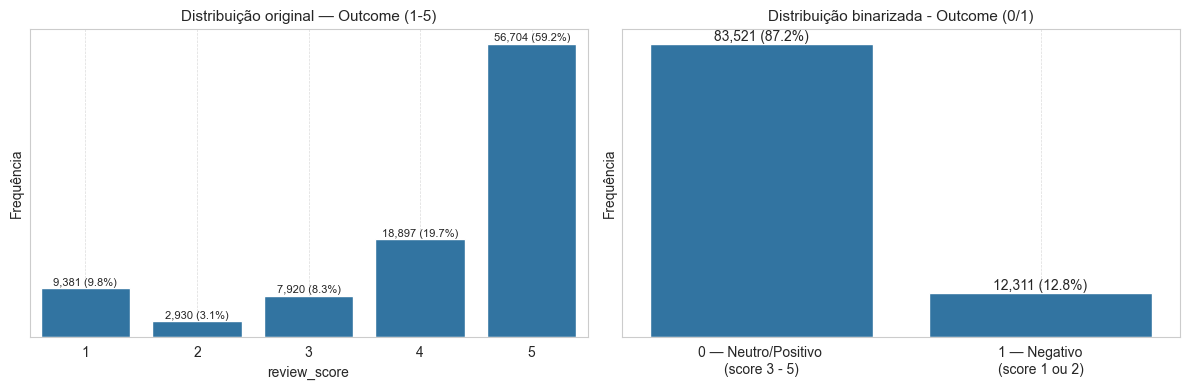

In [19]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[raw_outcome].value_counts().sort_index().dropna()

sns.barplot(
    x=counts.index,
    y=counts.values,
    ax=axes[0]
)

for i, val in enumerate(counts.values):
    axes[0].text(i, val + 100,
                 f'{val:,} ({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=8)

axes[0].set_title('Distribuição original — Outcome (1-5)', fontsize=11)
axes[0].set_xlabel(raw_outcome)
axes[0].set_ylabel('Frequência')
axes[0].set_xticks([0, 1, 2, 3, 4])
axes[0].set_xticklabels([1, 2, 3, 4, 5])

axes[0].set_yticks([])
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


sc = df[outcome].value_counts().sort_index()
labels2 = ['0 — Neutro/Positivo \n(score 3 - 5)', '1 — Negativo\n(score 1 ou 2)']

sns.barplot(
    x=labels2,
    y=sc.values,
    ax=axes[1]
)

for i, val in enumerate(sc.values):
    axes[1].text(i, val + 100,
                 f'{val:,} ({val/sc.sum()*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].set_title('Distribuição binarizada - Outcome (0/1)', fontsize=11)
axes[1].set_ylabel('Frequência')

axes[1].set_yticks([])
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
# plt.savefig(f'{PROJECT_DIR}/reports/figures/eda_v2_outcome.png',
plt.show()

## Descriptive analysis by domain 

main domains: Financial, orders, product, logistic, temporal

In [20]:
dominios = {
    'Financeiro': ['total_price', 'avg_price', 'total_freight', 'avg_freight', 'total_payment', 'avg_payment', 
                   'installment_value', 'is_high_freight_ratio', 'is_high_value_order', 'is_high_installments'],
    'Pedido': ['n_items', 'n_item_distinct_categ', 'n_items_missing_info', 'max_installments', 'n_payments_type'],
    'Produto': ['avg_weight', 'avg_length', 'avg_height', 'avg_width', 'volume_cm3', 'is_heavy_item', 'is_large_item'],
    'Logístico': ['delay_days', 'is_delayed', 'is_slightly_delayed', 'is_severely_delayed'],
    'Temporal': ['purchase_weekday', 'purchase_month']
}

In [21]:
rows = []
for dominio, cols in dominios.items():
    for col in cols:
        if col not in df.columns:
            continue
        s = df[col].dropna()
        rows.append({
            'Domínio':  dominio,
            'Variável': col,
            'N': f'{len(s):,}',
            'Média': round(s.mean(), 2),
            'DP': round(s.std(), 2),
            'Mediana': round(s.median(), 2),
            'IQR': round(s.quantile(0.75) - s.quantile(0.25), 2),
            'Mín': round(s.min(), 2),
            'Máx': round(s.max(), 2),
        })

pd.DataFrame(rows).set_index(['Domínio', 'Variável'])

N     Média        DP  Mediana  \
Domínio    Variável                                                     
Financeiro total_price            95,832    136.80    207.78    86.25   
           avg_price              95,832    125.04    188.30    79.00   
           total_freight          95,832     22.76     21.52    17.16   
           avg_freight            95,832     20.14     15.67    16.35   
           total_payment          95,831    159.59    217.51   105.28   
           avg_payment            95,831    156.97    214.92   103.11   
           installment_value      95,831       inf       NaN    53.56   
           is_high_freight_ratio  95,832      0.35      0.48     0.00   
           is_high_value_order    95,832      0.25      0.43     0.00   
           is_high_installments   95,832      0.12      0.33     0.00   
Pedido     n_items                95,832      1.14      0.53     1.00   
           n_item_distinct_categ  95,832      1.13      0.55     1.00   
           n_items_missing_info   95,832      0.02      0.14     0.00   
           max_installments       95,831      2.93      2.71     2.00   
           n_payments_type        95,831      1.04      0.37     1.00   
Produto    avg_weight             95,816   2095.19   3741.05   700.00   
           avg_length             95,816     30.07     16.03    25.00   
           avg_height             95,816     16.44     13.24    13.00   
           avg_width              95,816     23.00     11.68    20.00   
           volume_cm3             95,816  15121.58  23170.55  6400.00   
           is_heavy_item          95,832      0.40      0.49     0.00   
           is_large_item          95,832      0.50      0.50     0.00   
Logístico  delay_days             95,824    -11.91     10.11   -12.00   
           is_delayed             95,832      0.07      0.25     0.00   
           is_slightly_delayed    95,832      0.04      0.19     0.00   
           is_severely_delayed    95,832      0.03      0.17     0.00   
Temporal   purchase_weekday       95,832      2.76      1.97     3.00   
           purchase_month         95,832      6.03      3.23     6.00   

                                       IQR     Mín        Máx  
Domínio    Variável                                            
Financeiro total_price              104.00    0.85   13440.00  
           avg_price                 98.00    0.85    6735.00  
           total_freight             10.15    0.00    1794.96  
           avg_freight                7.78    0.00     409.68  
           total_payment            114.32    9.59   13664.08  
           avg_payment              114.08    1.74   13664.08  
           installment_value         64.43    3.77        inf  
           is_high_freight_ratio      1.00    0.00       1.00  
           is_high_value_order        0.00    0.00       1.00  
           is_high_installments       0.00    0.00       1.00  
Pedido     n_items                    0.00    1.00      21.00  
           n_item_distinct_categ      0.00    0.00      21.00  
           n_items_missing_info       0.00    0.00       6.00  
           max_installments           3.00    0.00      24.00  
           n_payments_type            0.00    1.00      26.00  
Produto    avg_weight              1500.00    0.00   40425.00  
           avg_length                20.00    7.00     105.00  
           avg_height                12.00    2.00     105.00  
           avg_width                 15.00    6.00     118.00  
           volume_cm3             15224.00  168.00  296208.00  
           is_heavy_item              1.00    0.00       1.00  
           is_large_item              1.00    0.00       1.00  
Logístico  delay_days                10.00 -147.00     188.00  
           is_delayed                 0.00    0.00       1.00  
           is_slightly_delayed        0.00    0.00       1.00  
           is_severely_delayed        0.00    0.00       1.00  
Temporal   purchase_weekday           3.00    0.00      

## Continous features distribution

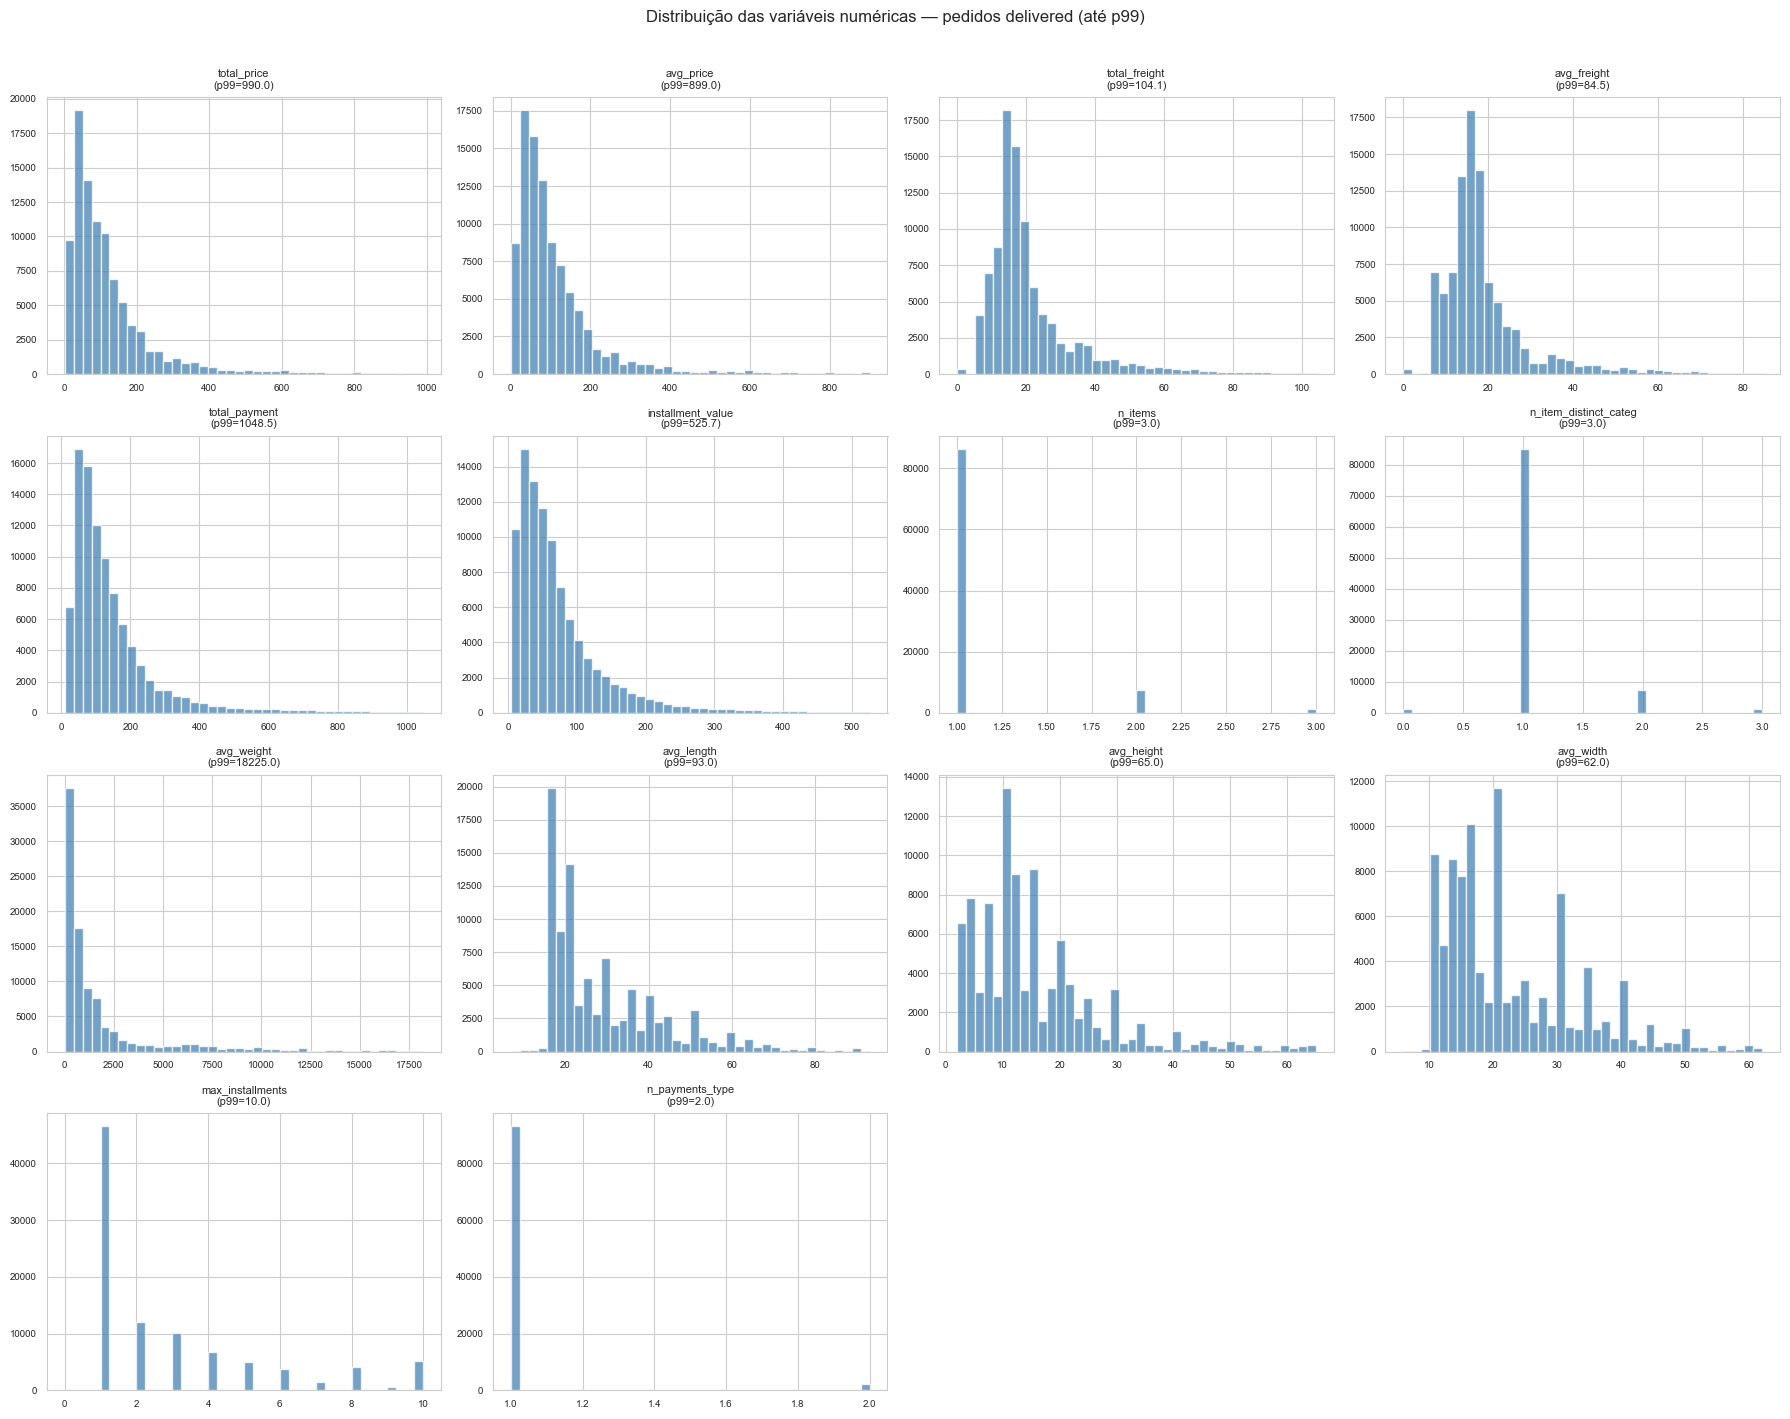

In [22]:
numericas = [
    'total_price', 'avg_price', 'total_freight', 'avg_freight',
    'total_payment', 'installment_value',
    'n_items', 'n_item_distinct_categ', 'avg_weight',
    'avg_length', 'avg_height', 'avg_width',
    'max_installments', 'n_payments_type'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numericas):
    data = df[col].dropna()
    p99  = data.quantile(0.99)
    data_plot = data[data <= p99]
    axes[i].hist(data_plot, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(f'{col}\n(p99={p99:.1f})', fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das variáveis numéricas — pedidos delivered (até p99)', fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig('../../reports/figures/eda_v2_numericas.png', dpi=120, bbox_inches='tight')
plt.show()

## Categorical and temporal features distribution

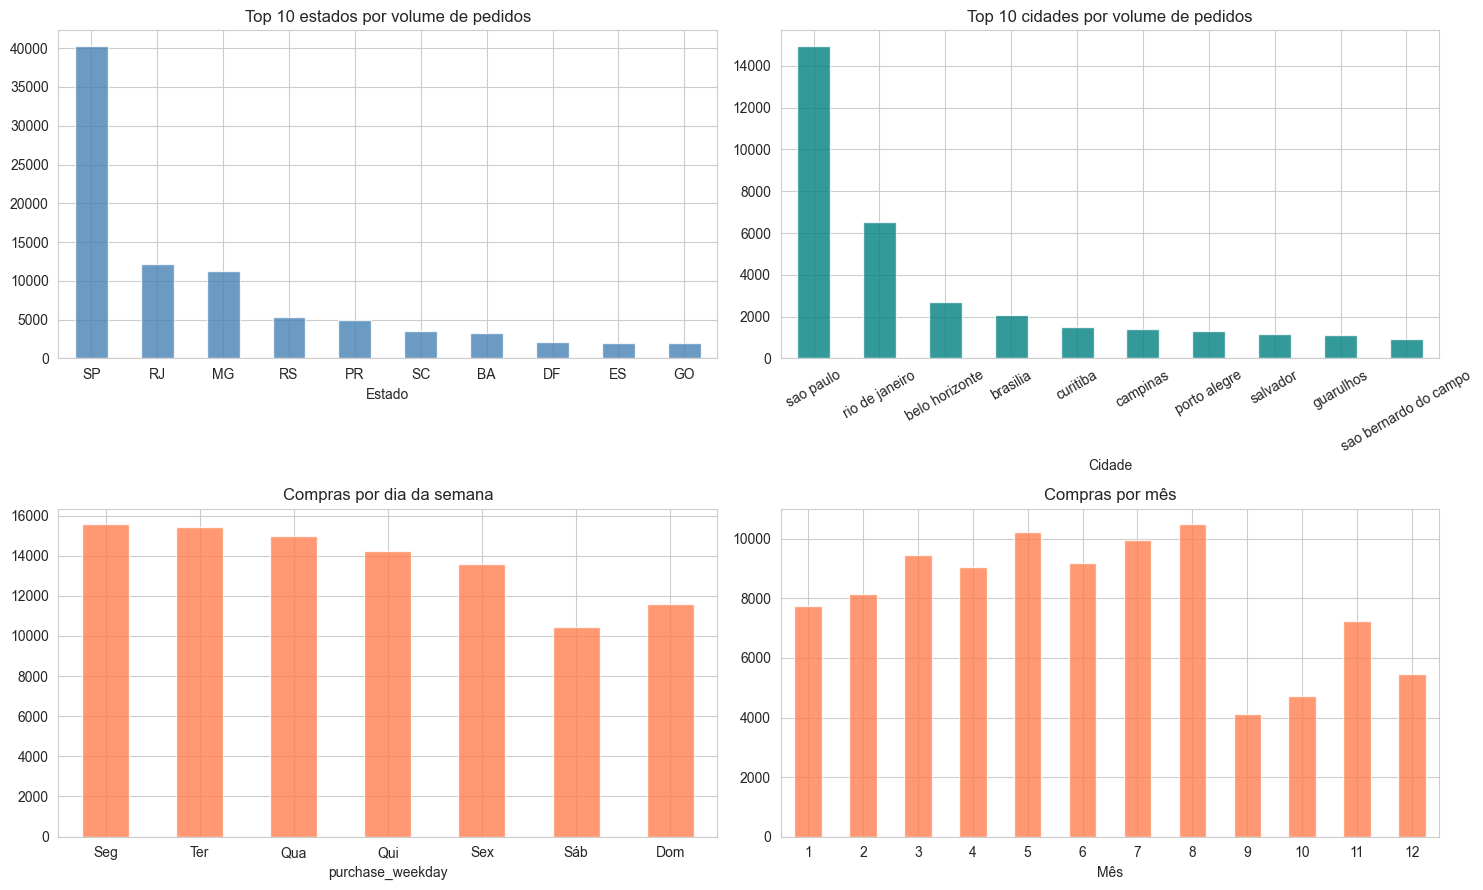

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Top 10 estados
df['customer_state'].value_counts().head(10).plot(
    kind='bar', ax=axes[0,0], color='steelblue', alpha=0.8
)
axes[0,0].set_title('Top 10 estados por volume de pedidos')
axes[0,0].set_xlabel('Estado')
axes[0,0].tick_params(axis='x', rotation=0)

df['customer_city'].value_counts().head(10).plot(
    kind='bar', ax=axes[0,1], color='teal', alpha=0.8
)
axes[0,1].set_title('Top 10 cidades por volume de pedidos')
axes[0,1].set_xlabel('Cidade')
axes[0,1].tick_params(axis='x', rotation=30)

# Dia da semana
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
df['purchase_weekday'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,0], color='coral', alpha=0.8
)
axes[1,0].set_title('Compras por dia da semana')
axes[1,0].set_xticklabels(dias, rotation=0)

# Mês
df['purchase_month'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color='coral', alpha=0.8
)
axes[1,1].set_title('Compras por mês')
axes[1,1].set_xlabel('Mês')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../../reports/figures/eda_v2_categoricas.png', dpi=120)
plt.show()

## Association analysis: features and outcome (`score_review`)

In [24]:
binary_features = [
    'is_delayed', 'is_slightly_delayed', 'is_severely_delayed',
    'is_heavy_item', 'is_large_item', 'is_high_freight_ratio',
    'is_high_value_order', 'is_high_installments'
]

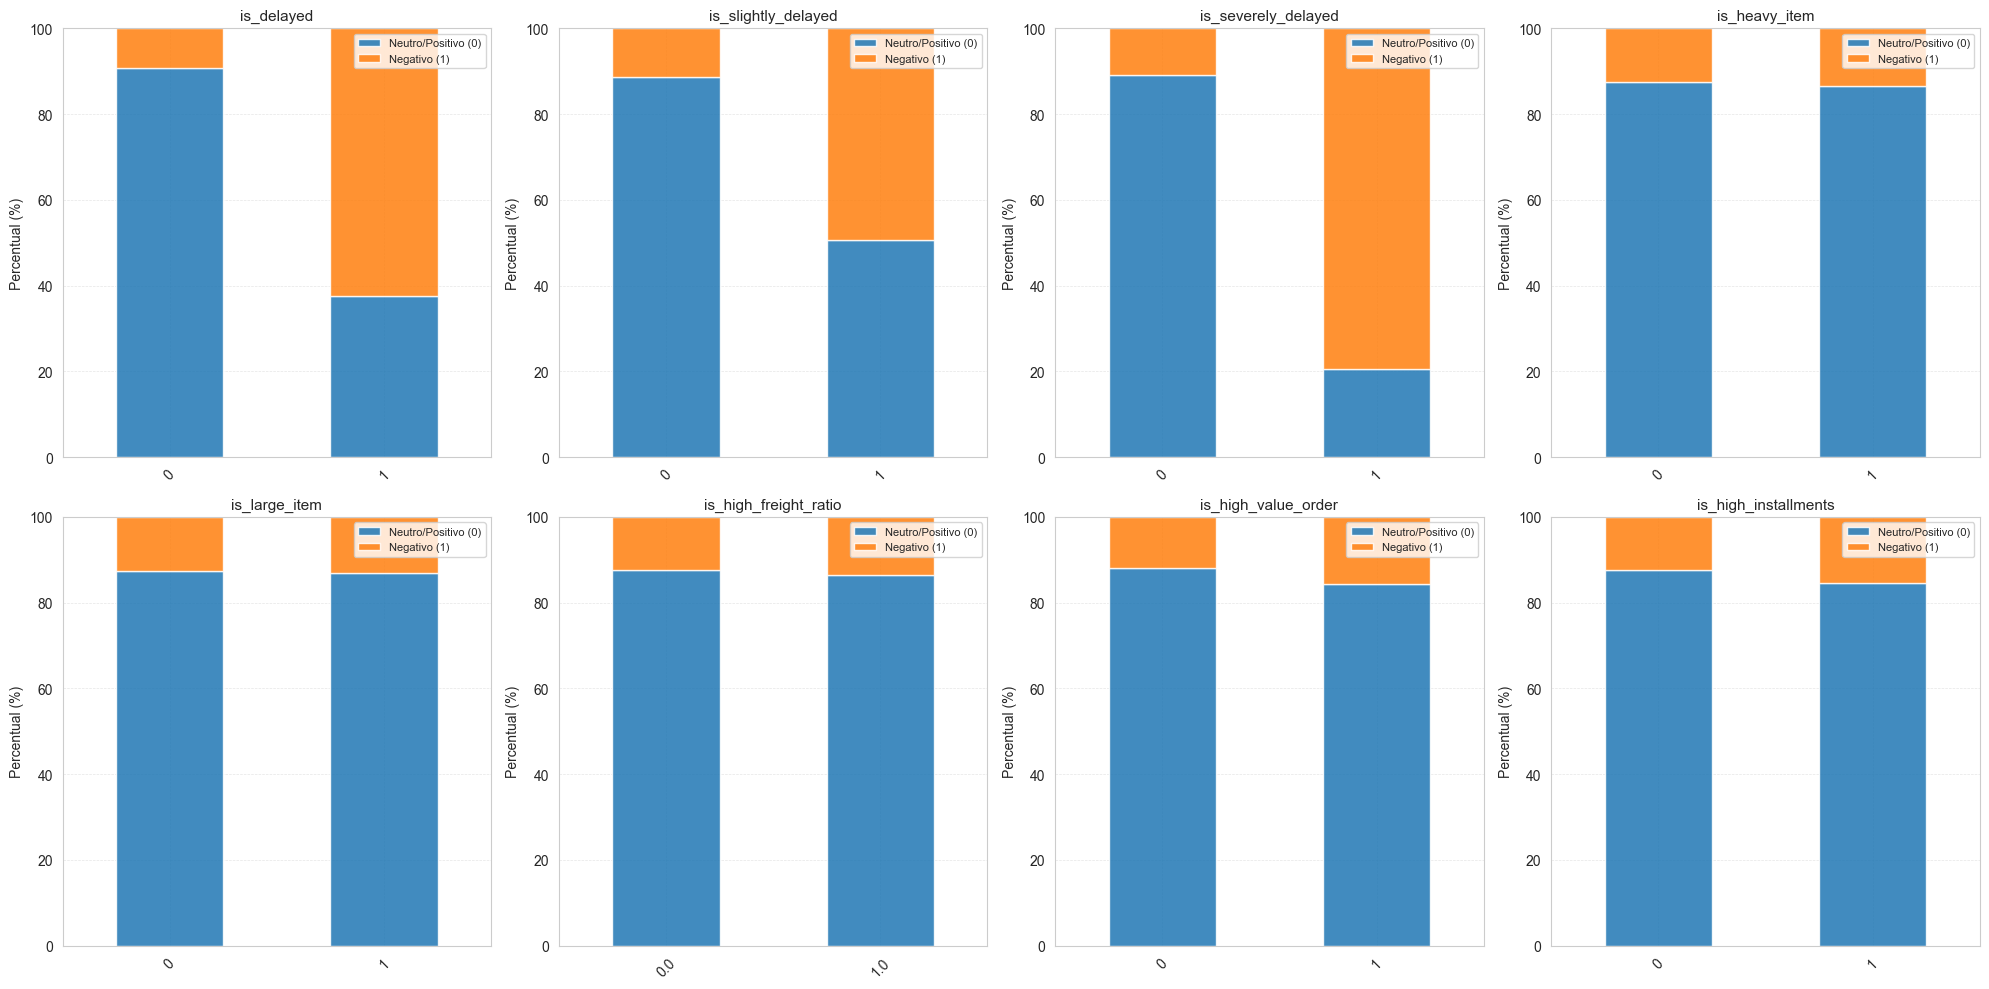

In [25]:
n = len(binary_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(binary_features):
        
    temp = (
        df
        .groupby(col)[outcome]
        .value_counts(normalize=True)
        .rename('perc')
        .mul(100)
        .reset_index()
        .pivot(index=col, columns=outcome, values='perc')
        .fillna(0)
    )
    
    temp = temp.sort_index()
    
    temp[[0, 1]].plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        alpha=0.85
    )
    
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentual (%)')
    axes[i].set_ylim(0, 100)
    
    axes[i].legend(['Neutro/Positivo (0)', 'Negativo (1)'], fontsize=8)
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(binary_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [26]:
other_categ_features = ['customer_state', 'purchase_month', 'purchase_weekday']

dias_map = {0: "seg", 1: "ter", 2: "quar", 3: "qui", 4: "sex", 5: "sáb", 6: "dom"}

meses_map = {
    1: "jan", 2: "fev", 3: "mar", 4: "abr",
    5: "mai", 6: "jun", 7: "jul", 8: "ago",
    9: "set", 10: "out", 11: "nov", 12: "dez"
}

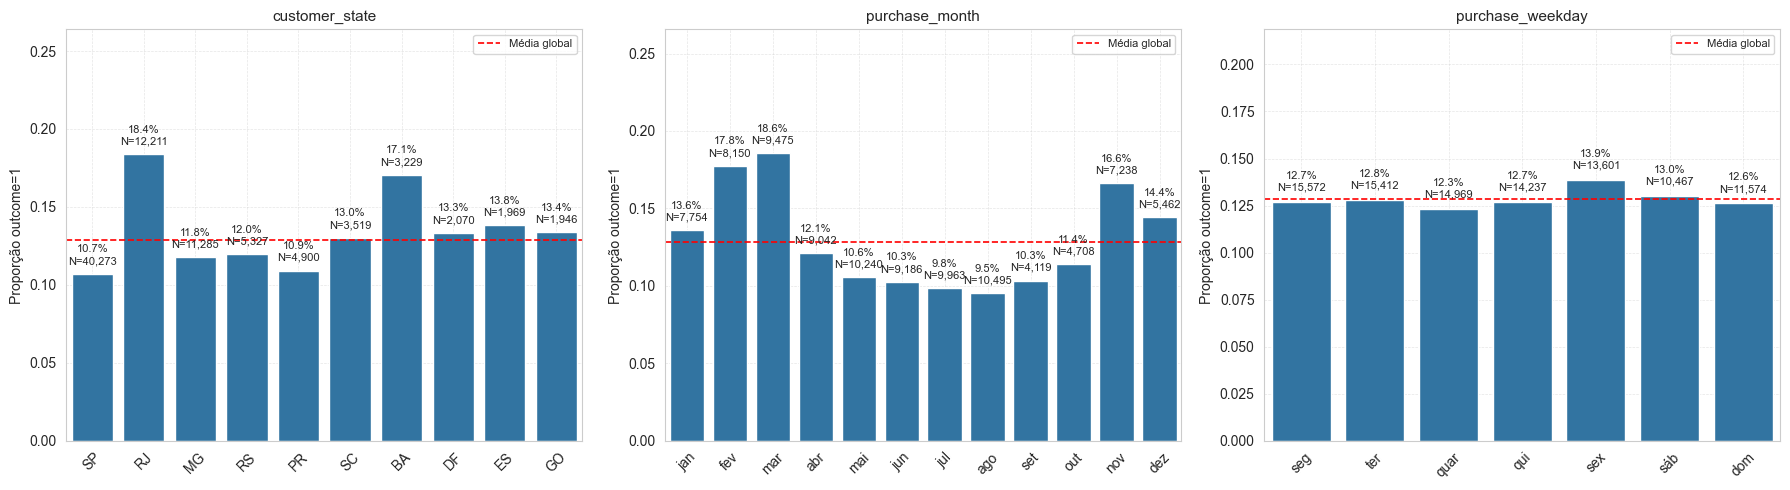

In [27]:
n = len(other_categ_features)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

global_mean = df[outcome].mean()

for i, col in enumerate(other_categ_features):

    stats = (
        df.groupby(col)[outcome]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'taxa', 'count': 'N'})
        .reset_index()
    )

    if col == 'customer_state':
        stats = stats.sort_values('N', ascending=False).head(10)
        stats[col] = stats[col].astype(str)

    elif col == 'purchase_weekday':
        stats = stats.copy()
        stats[col] = stats[col].map(dias_map)

        ordem = ['seg', 'ter', 'quar', 'qui', 'sex', 'sáb', 'dom']
        stats[col] = pd.Categorical(stats[col], categories=ordem, ordered=True)
        stats = stats.sort_values(col)

    elif col == 'purchase_month':
        stats = stats.copy()
        stats[col] = stats[col].map(meses_map)

        ordem = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun',
                 'jul', 'ago', 'set', 'out', 'nov', 'dez']
        stats[col] = pd.Categorical(stats[col], categories=ordem, ordered=True)
        stats = stats.sort_values(col)

    sns.barplot(
        data=stats,
        x=col,
        y='taxa',
        ax=axes[i]
    )

    axes[i].axhline(
        global_mean,
        color='red',
        linestyle='--',
        linewidth=1.2,
        label='Média global'
    )

    for j, (_, row) in enumerate(stats.iterrows()):
        axes[i].text(
            j,
            row['taxa'] + 0.005,
            f"{row['taxa']*100:.1f}%\nN={row['N']:,}",
            ha='center',
            va='bottom',
            fontsize=8
        )

    axes[i].legend(fontsize=8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proporção outcome=1')
    axes[i].set_ylim(0, min(1, stats['taxa'].max() + 0.08))
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(other_categ_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [28]:
num_cols = [
    'total_price', 'avg_price', 'total_freight', 'avg_freight', 
    'total_payment', 'installment_value', 'max_installments', 'n_payments_type',
    'n_items', 'n_item_distinct_categ', 'n_items_missing_info',
    'avg_weight', 'avg_length', 'avg_height', 'avg_width', 'volume_cm3',
    'delay_days'
]

In [29]:
df_num = df[[outcome] + num_cols].replace([np.inf, -np.inf], np.nan)
g = df_num.groupby(outcome)

df_assoc = (
    pd.DataFrame({
        'feature': num_cols,
        'mean outcome = 0': [g.get_group(0)[col].mean() for col in num_cols],
        'mean outcome = 1': [g.get_group(1)[col].mean() for col in num_cols]
    })
    .assign(**{
        'diff': lambda d: d['mean outcome = 1'] - d['mean outcome = 0'],
        'relav_diff_%': lambda d: np.where(
            (d['mean outcome = 0'] != 0) & d['mean outcome = 0'].notna(),
            (d['diff'] / d['mean outcome = 0']) * 100,
            np.nan
        )
    })
    .sort_values('diff', key=np.abs, ascending=False)
    .round({
        'mean outcome = 0': 2,
        'mean outcome = 1': 2,
        'diff': 3,
        'relav_diff_%': 1
    })
)

df_assoc

,feature,mean outcome = 0,mean outcome = 1,diff,relav_diff_%
15,volume_cm3,14919.01,16496.00,1576.990,10.6
11,avg_weight,2058.60,2343.47,284.878,13.8
4,total_payment,155.46,187.67,32.219,20.7
0,total_price,133.40,159.91,26.519,19.9
5,installment_value,80.52,92.09,11.568,14.4
16,delay_days,-12.91,-5.15,7.760,-60.1
1,avg_price,124.06,131.73,7.675,6.2
2,total_freight,22.03,27.72,5.685,25.8
3,avg_freight,19.95,21.46,1.512,7.6
13,avg_height,16.35,17.00,0.647,4.0


## Spearman correlation between numeric features and outcome before binarization

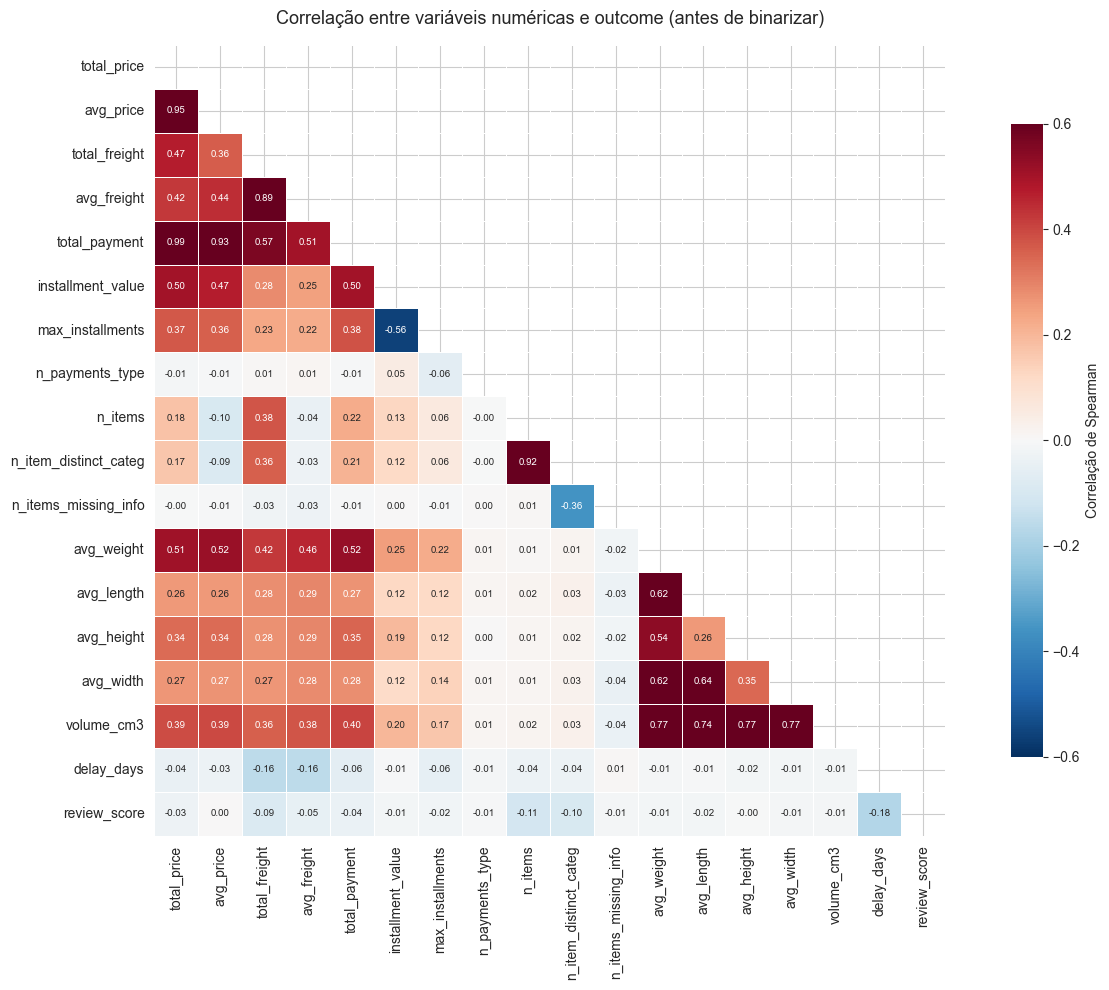

In [30]:
cols_corr = num_cols + [raw_outcome]

# Spearman é mais apropriado para outcome ordinal
corr = df[cols_corr].corr(method = 'spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlação de Spearman'},
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Correlação entre variáveis numéricas e outcome (antes de binarizar)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [31]:
df_corr_outcome = (
    corr[[raw_outcome]]
    .drop(index=raw_outcome)
    .rename(columns={raw_outcome: 'corr_spearman'})
    .assign(corr_abs=lambda d: d['corr_spearman'].abs())
    .sort_values('corr_abs', ascending=False)
    .drop(columns='corr_abs')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

df_corr_outcome

,feature,corr_spearman
0,delay_days,-0.176066
1,n_items,-0.108140
2,n_item_distinct_categ,-0.096376
3,total_freight,-0.088571
4,avg_freight,-0.049767
5,total_payment,-0.039115
6,total_price,-0.028984
7,max_installments,-0.021629
8,avg_length,-0.015573
9,installment_value,-0.014324


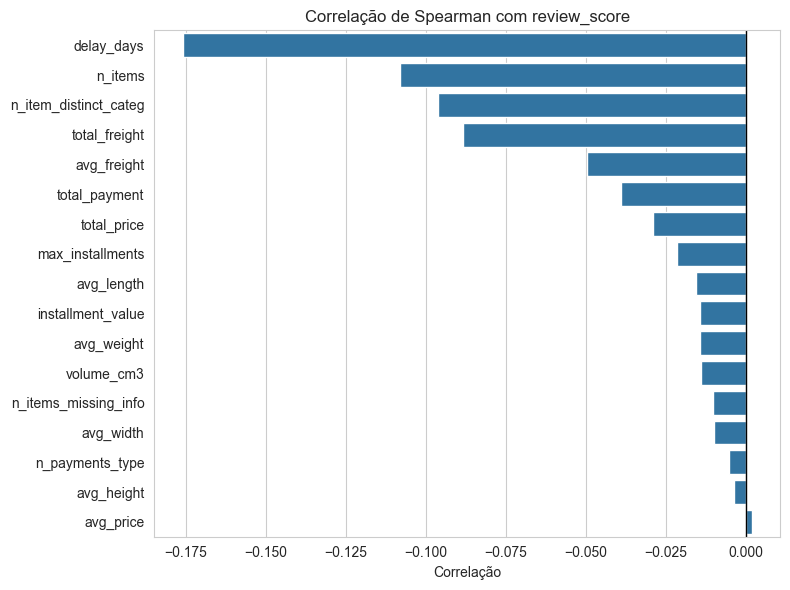

In [32]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_corr_outcome,
    x='corr_spearman',
    y='feature'
)

plt.axvline(0, color='black', linewidth=1)
plt.title(f'Correlação de Spearman com {raw_outcome}')
plt.xlabel('Correlação')
plt.ylabel('')
plt.tight_layout()

plt.show()

# Analysis of `is_delayed` — Strongest candidate for treatment

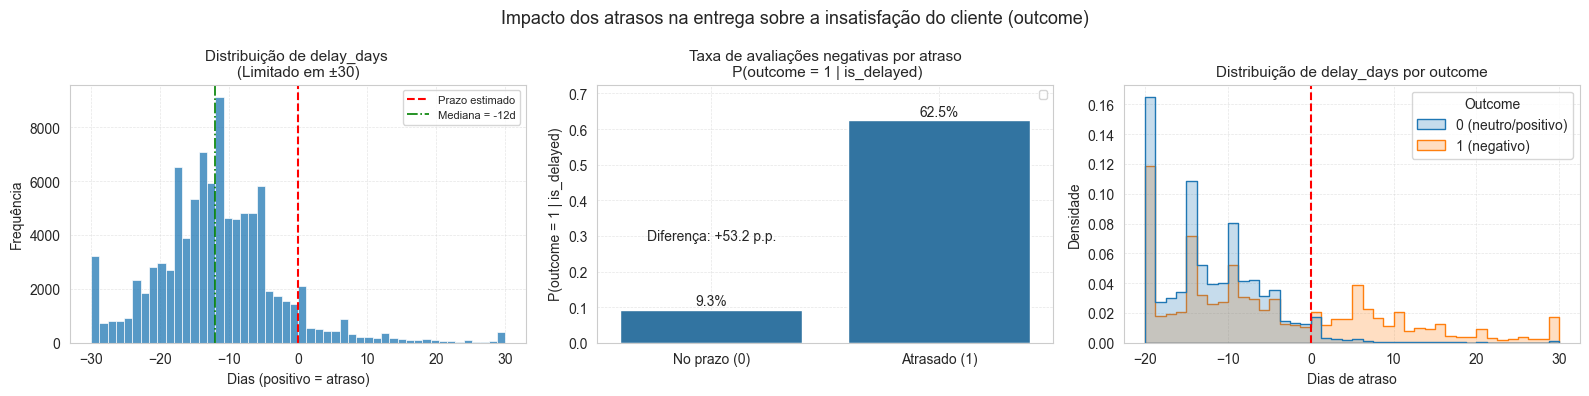

In [52]:
med_delay = df['delay_days'].median()
global_mean = df[outcome].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
delay_clip = df['delay_days'].clip(-30, 30)

sns.histplot(delay_clip, bins=50, ax=axes[0])

axes[0].axvline(0, linestyle='--', linewidth=1.5, label='Prazo estimado', color='red')
axes[0].axvline(med_delay, linestyle = '-.', linewidth = 1.2, label = f'Mediana = {med_delay:.0f}d', color='green')
axes[0].set_title('Distribuição de delay_days \n(Limitado em ±30)', fontsize=11)
axes[0].set_xlabel('Dias (positivo = atraso)')
axes[0].set_ylabel('Frequência')
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
axes[0].legend(fontsize=8)


taxa_delay = df.groupby('is_delayed')[outcome].mean().sort_index()
labels = ['No prazo (0)', 'Atrasado (1)']

sns.barplot(
    x=labels,
    y=taxa_delay.values,
    ax=axes[1]
)

for i, val in enumerate(taxa_delay.values):
    axes[1].text(
        i, val + 0.005,
        f'{val*100:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

diff_pp = (taxa_delay[1] - taxa_delay[0]) * 100

axes[1].text(
    0.25, 0.40,
    f'Diferença: {diff_pp:+.1f} p.p.',
    ha='center',
    transform=axes[1].transAxes,
    fontsize=10
)
axes[1].set_title('Taxa de avaliações negativas por atraso\n P(outcome = 1 | is_delayed)', fontsize=11)
axes[1].set_ylabel('P(outcome = 1 | is_delayed)')
axes[1].set_ylim(0, min(1, taxa_delay.max() + 0.1))
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
axes[1].legend(fontsize=8)



df_plot = df.copy()
df_plot['delay_clip'] = df_plot['delay_days'].clip(-20, 30)
df_plot['Outcome'] = df_plot[outcome].map({0: '0 (neutro/positivo)', 1: '1 (negativo)'})
df_plot['Outcome'] = pd.Categorical(df_plot['Outcome'], categories=['0 (neutro/positivo)', '1 (negativo)'], ordered=True)

sns.histplot(
    data=df_plot,
    x='delay_clip',
    hue='Outcome',
    hue_order=['0 (neutro/positivo)', '1 (negativo)'],
    bins=40,
    element='step',
    stat='density',
    common_norm=False,
    ax=axes[2]
)

axes[2].axvline(0, linestyle='--', linewidth=1.5, label='Prazo estimado', color='red')
axes[2].set_title('Distribuição de delay_days por outcome', fontsize=11)
axes[2].set_xlabel('Dias de atraso')
axes[2].set_ylabel('Densidade')
axes[2].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Impacto dos atrasos na entrega sobre a insatisfação do cliente (outcome)', fontsize=13)
plt.tight_layout()
# plt.savefig(f'{PROJECT_DIR}/reports/figures/eda_v2_is_delayed.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Prevalência das features binárias/discretas candidatas a tratamento

In [34]:
candidatos = {
    # Logístico — atraso
    'is_delayed (>0d)': df_analysis['is_delayed'],
    'is_slightly_delayed (1-7d)': df_analysis['is_slightly_delayed'],
    'is_severely_delayed (>7d)': df_analysis['is_severely_delayed'],
    # Pedido
    'pedido_multi_item': (df_analysis['n_items'] > 1).astype(int),
    'pedido_multi_categ': (df_analysis['n_item_distinct_categ'] > 1).astype(int),
    # Produto
    'is_heavy_item (>1kg)': df_analysis['is_heavy_item'],
    'is_large_item (>med)': df_analysis['is_large_item'],
    # Financeiro
    'is_high_freight_ratio': df_analysis['is_high_freight_ratio'],
    'is_high_value_order (>p75)': df_analysis['is_high_value_order'],
    'is_high_installments (>6x)': df_analysis['is_high_installments'],
    'parcelado (>1x)': (df_analysis['max_installments'] > 1).astype(int),
}

In [35]:
rows = []
y = df_analysis[outcome]

for label, serie in candidatos.items():
    
    s = serie.reindex(df_analysis.index).dropna()
    
    mask1 = s == 1
    mask0 = s == 0
    
    n1 = mask1.sum()
    n0 = mask0.sum()
    
    prev = mask1.mean()
    
    t1 = y[mask1].mean()
    t0 = y[mask0].mean()
    
    diff_pp = (t1 - t0) * 100
    
    # regra de overlap (IPTW)
    if prev < 0.05:
        ok = 'BAIXA'
    elif prev > 0.95:
        ok = 'ALTA'
    else:
        ok = 'OK'
    
    rows.append({
        'Variável': label,
        'Prevalência': prev,
        'N T=1': n1,
        'N T=0': n0,
        'Score T=1': t1,
        'Score T=0': t0,
        'Diff (p.p.)': diff_pp,
        'OK IPTW': ok
    })

df_prev = (
    pd.DataFrame(rows)
    .sort_values('Diff (p.p.)', key=np.abs, ascending=False)
)

df_prev

,Variável,Prevalência,N T=1,N T=0,Score T=1,Score T=0,Diff (p.p.),OK IPTW
2,is_severely_delayed (>7d),0.029020,2781,93051,0.793599,0.108586,68.501381,BAIXA
0,is_delayed (>0d),0.066585,6381,89451,0.624667,0.093068,53.159927,OK
1,is_slightly_delayed (1-7d),0.037566,3600,92232,0.494167,0.114190,37.997636,BAIXA
3,pedido_multi_item,0.099424,9528,86304,0.268997,0.112950,15.604707,OK
4,pedido_multi_categ,0.097932,9385,86447,0.267661,0.113353,15.430847,OK
8,is_high_value_order (>p75),0.247350,23704,72128,0.155712,0.119510,3.620236,OK
9,is_high_installments (>6x),0.121692,11662,84170,0.153747,0.124961,2.878583,OK
10,parcelado (>1x),0.514557,49311,46521,0.136866,0.119559,1.730710,OK
7,is_high_freight_ratio,0.351219,33658,62174,0.136164,0.124296,1.186744,OK
5,is_heavy_item (>1kg),0.398406,38180,57652,0.134311,0.124592,0.971878,OK


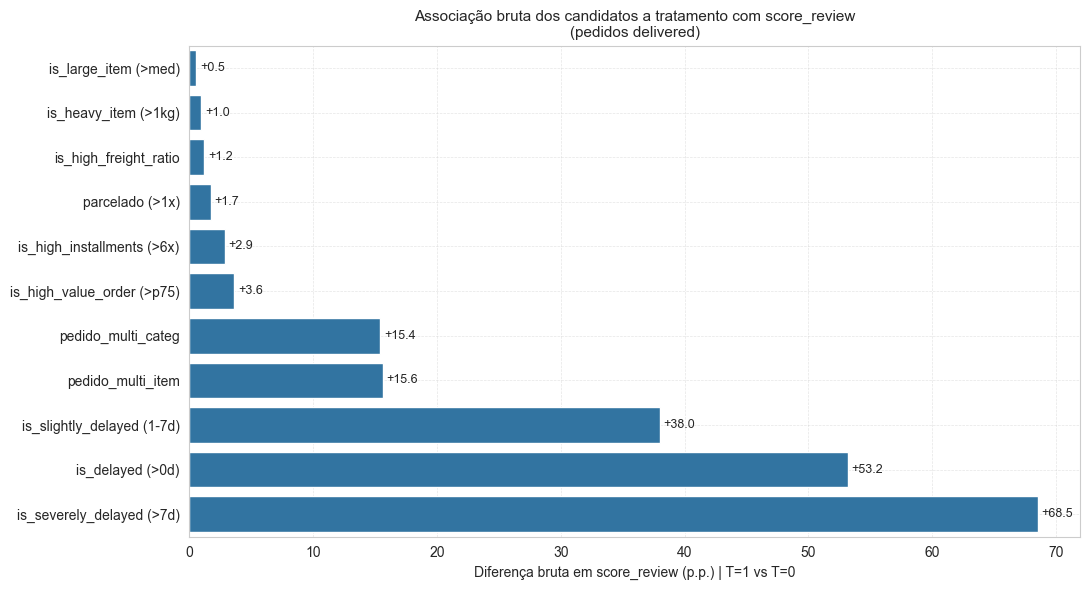

In [36]:
df_plot = df_prev.sort_values('Diff (p.p.)')

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=df_plot,
    x='Diff (p.p.)',
    y='Variável',
    ax=ax
)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2)

for i, val in enumerate(df_plot['Diff (p.p.)']):
    offset = 0.3 if val >= 0 else -0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        val + offset,
        i,
        f'{val:+.1f}',
        va='center',
        ha=ha,
        fontsize=9
    )

ax.set_xlabel('Diferença bruta em score_review (p.p.) | T=1 vs T=0')
ax.set_ylabel('')
ax.set_title(
    'Associação bruta dos candidatos a tratamento com score_review\n(pedidos delivered)',
    fontsize=11
)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
# plt.savefig(f'{PROJECT_DIR}/reports/figures/eda_v2_candidatos.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

# Conclusão

Das análises realizadas ao longo deste notebook, notou-se que, de forma consistente, o atraso na entrega é o fator que mais fortemente afeta a ocorrência de avaliações negativas por parte dos clientes. Em particular, a variável binária que indica se o pedido foi entregue com atraso (`is_delayed`) apresentou a maior diferença em pontos percentuais na taxa de insatisfação quando comparada às demais variáveis analisadas, evidenciando um impacto substancial sobre o \textit{outcome} (com exceção da variável  `is_severely_delayed`, cujo efeito, embora ainda mais pronunciado, é esperado por construção e, portanto, menos informativo do ponto de vista analítico). 

Observa-se que pedidos entregues fora do prazo possuem probabilidade significativamente maior de receber avaliações negativas, resultado que se mantém robusto em diferentes abordagens, incluindo análises condicionais e distribuições de `delay_days` segmentadas por \textit{outcome}. Embora outras variáveis, como características financeiras, físicas dos produtos e atributos do pedido, também apresentem associação com o desfecho, seus efeitos são consideravelmente menores, sugerindo que fatores logísticos — em especial o cumprimento do prazo de entrega — desempenham papel central na experiência do cliente. Dessa forma, os resultados obtidos fornecem evidências empíricas para a escolha do atraso na entrega como variável de tratamento principal nas etapas subsequentes de modelagem causal, permitindo investigar de maneira mais rigorosa seu efeito sobre a probabilidade de avaliações negativas, controlando para potenciais variáveis de confusão.